In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
def from_pickle(filename):
    with open(filename, "rb") as file:
        return pickle.load(file)

In [3]:
models = ['LEDRBO', 'SBOKDE', 'UCB', 'WassersteinUCB', 'EmpiricalUCB', 'DRBOKDE', 'Stable', 'MMD', 'MMD_Minimax_Approx']

In [4]:
functions = ['ThreeHumpCamel', 'SixHumpCamel', 'Ackley',
             'Hartmann', 'Hartmann_complicated', 'Modified_Branin' ,
             'Continuous_Vendor','portfolio_optimization', 'portfolio_normal_optimization']

In [5]:
name_to_title = {
     'ThreeHumpCamel': 'Three-Hump Camel' ,
     'Ackley': 'Ackley',
     'Hartmann': 'Hartmann',
     'Modified_Branin': 'Modified Branin',
     'portfolio_optimization': 'Portfolio (Uniform)',
     'portfolio_normal_optimization': 'Portfolio (Normal)',
     'Continuous_Vendor': 'Newsvendor',
     'SixHumpCamel': 'Six-Hump Camel',
     'Hartmann_complicated': 'Hartmann (Complicated)'
}

In [6]:
method_to_name = {
    'LEDRBO': 'EDRBO (Ours)',
    'LEDRBO_': 'EDRBO (Smooth)',
    'SBOKDE': 'SBO-KDE',
    'UCB': 'UCB',
    'WassersteinUCB': 'WDRBO',
    'EmpiricalUCB': 'ERBO',
    'DRBOKDE': 'DRBO-KDE',
    'Stable': 'StableOpt',
    'MMD': 'DRBO-MMD',
    'MMD_Minimax_Approx': 'DRBO-MMD Minmax'
}

In [7]:
res = dict.fromkeys(functions)

In [8]:
for f in res.keys():
    res[f] = dict.fromkeys(models)

In [9]:
for f in res.keys():
    for m in res[f].keys():
        res[f][m] = [entry for entry in os.listdir(f'Result/') if entry.startswith(f'{m}_{f}')]

In [10]:
def read_experiment(files, get_time=False):
    experiments = []    

    for f in files:
        exp = from_pickle(f'Result/'+f)
        
        if get_time:
            experiments.append(exp.get("time"))
        else:
            experiments.append([arr.item() for arr in exp.get("cumulative_regret")])

    return np.array(experiments)

In [11]:
for f in res.keys():
    for m in res[f].keys():
        res[f][m] = read_experiment(res[f][m])

In [12]:
temp_res = dict.fromkeys(functions)
for f in res.keys():
    temp_res[f] = dict.fromkeys(models)

In [13]:
for f in functions:
    for m in models:
        temp_res[f][m] = f'{np.round(np.mean(res[f][m]), 2)} ± {np.round(np.std(res[f][m]), 2)}'

In [14]:
temp_res = pd.DataFrame(temp_res)

In [15]:
temp_res.rename(index=method_to_name)

,ThreeHumpCamel,SixHumpCamel,Ackley,Hartmann,Hartmann_complicated,Modified_Branin,Continuous_Vendor,portfolio_optimization,portfolio_normal_optimization
EDRBO (Ours),2.9 ± 0.5,96.34 ± 85.47,195.02 ± 67.8,62.73 ± 30.08,70.93 ± 36.8,726.01 ± 257.04,6.89 ± 1.61,299.11 ± 120.27,420.49 ± 171.92
SBO-KDE,3.13 ± 1.09,105.08 ± 81.19,332.33 ± 160.31,79.05 ± 53.63,93.89 ± 62.65,754.6 ± 309.47,9.6 ± 2.63,325.17 ± 105.61,447.37 ± 160.39
UCB,5.44 ± 2.03,81.23 ± 56.36,318.12 ± 151.63,112.51 ± 65.41,125.46 ± 69.64,908.2 ± 460.49,12.07 ± 5.5,358.22 ± 134.73,574.02 ± 293.95
WDRBO,3.39 ± 1.11,145.8 ± 65.43,409.87 ± 175.31,72.6 ± 36.98,88.49 ± 44.9,807.67 ± 233.47,10.71 ± 3.43,373.11 ± 138.79,505.98 ± 202.28
ERBO,3.15 ± 1.06,107.7 ± 83.5,269.17 ± 127.19,66.9 ± 35.55,75.35 ± 43.37,685.02 ± 266.35,10.44 ± 3.45,347.44 ± 105.25,448.87 ± 169.05
DRBO-KDE,3.44 ± 1.31,106.68 ± 82.88,377.28 ± 171.38,94.97 ± 58.46,106.97 ± 58.22,883.97 ± 313.51,11.63 ± 4.05,437.22 ± 179.21,533.35 ± 224.77
StableOpt,30.81 ± 18.31,178.98 ± 65.19,734.37 ± 388.01,185.61 ± 99.74,173.42 ± 92.84,2301.76 ± 1461.35,45.27 ± 24.17,734.99 ± 366.79,807.47 ± 354.31
DRBO-MMD,5.38 ± 1.96,129.74 ± 36.26,510.58 ± 217.32,153.08 ± 70.14,159.04 ± 76.65,987.42 ± 371.17,36.18 ± 15.76,597.6 ± 247.67,644.69 ± 255.29
DRBO-MMD Minmax,7.08 ± 2.99,248.36 ± 103.97,599.73 ± 303.7,161.13 ± 78.21,159.01 ± 76.64,1241.81 ± 588.03,47.0 ± 24.36,644.61 ± 254.66,691.56 ± 296.39


In [16]:
temp_res = dict.fromkeys(functions)
for f in res.keys():
    temp_res[f] = dict.fromkeys(models)

In [17]:
for f in functions:
    for m in models:
        temp_res[f][m] = np.round(np.mean(res[f][m]), 3)

In [18]:
rk = pd.DataFrame(temp_res).rename(index=method_to_name)

# column_means = rk.mean(axis=0)
# rk = pd.concat([rk, pd.DataFrame([column_means], index=['Average per function'])])
row_means = round(rk.iloc[:, :].mean(axis=1), 2)
row_stds = round(rk.iloc[:, :].std(axis=1), 2)
rk_ = pd.concat([rk, pd.DataFrame([row_means], index=['Average per model']).T, pd.DataFrame([row_stds], index=['std per model']).T], axis=1)
rk_

,ThreeHumpCamel,SixHumpCamel,Ackley,Hartmann,Hartmann_complicated,Modified_Branin,Continuous_Vendor,portfolio_optimization,portfolio_normal_optimization,Average per model,std per model
EDRBO (Ours),2.897,96.335,195.022,62.731,70.931,726.014,6.886,299.113,420.486,208.94,238.96
SBO-KDE,3.127,105.079,332.331,79.049,93.891,754.601,9.597,325.174,447.373,238.91,249.56
UCB,5.443,81.225,318.120,112.508,125.463,908.201,12.066,358.218,574.023,277.25,301.50
WDRBO,3.386,145.796,409.865,72.604,88.491,807.667,10.711,373.110,505.985,268.62,274.00
ERBO,3.150,107.703,269.171,66.896,75.353,685.025,10.444,347.441,448.871,223.78,233.20
DRBO-KDE,3.437,106.680,377.283,94.973,106.968,883.969,11.631,437.223,533.346,283.95,297.01
StableOpt,30.811,178.982,734.370,185.611,173.416,2301.759,45.273,734.985,807.473,576.96,718.78
DRBO-MMD,5.382,129.735,510.575,153.083,159.037,987.420,36.182,597.599,644.694,358.19,339.23
DRBO-MMD Minmax,7.083,248.364,599.725,161.130,159.015,1241.810,47.005,644.607,691.563,422.26,404.05


In [19]:
rk = pd.DataFrame(temp_res).rename(index=method_to_name).rank(axis=0, method='average', numeric_only=False, na_option='keep', ascending=True, pct=False)
#
# column_means = rk.mean(axis=0)
# rk = pd.concat([rk, pd.DataFrame([column_means], index=['Average per function'])])
row_means = round(rk.iloc[:, :].mean(axis=1), 2)
rk_ = pd.concat([rk, pd.DataFrame([row_means], index=['Average per model']).T], axis=1)
rk_

,ThreeHumpCamel,SixHumpCamel,Ackley,Hartmann,Hartmann_complicated,Modified_Branin,Continuous_Vendor,portfolio_optimization,portfolio_normal_optimization,Average per model
EDRBO (Ours),1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.22
SBO-KDE,2.0,3.0,4.0,4.0,4.0,3.0,2.0,2.0,2.0,2.89
UCB,7.0,1.0,3.0,6.0,6.0,6.0,6.0,4.0,6.0,5.00
WDRBO,4.0,7.0,6.0,3.0,3.0,4.0,4.0,5.0,4.0,4.44
ERBO,3.0,5.0,2.0,2.0,2.0,1.0,3.0,3.0,3.0,2.67
DRBO-KDE,5.0,4.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.00
StableOpt,9.0,8.0,9.0,9.0,9.0,9.0,8.0,9.0,9.0,8.78
DRBO-MMD,6.0,6.0,7.0,7.0,8.0,7.0,7.0,7.0,7.0,6.89
DRBO-MMD Minmax,8.0,9.0,8.0,8.0,7.0,8.0,9.0,8.0,8.0,8.11


In [20]:
linestyles = dict.fromkeys(models)
linestyles['WDRBO3'] = (0, ())
linestyles['LEDRBO'] = (0, ())
linestyles['SBOKDE'] = (0, (3, 1, 1, 1, 1, 1))
linestyles['UCB'] = (0, (3, 1, 1, 1, 1))
linestyles['WassersteinUCB'] = (0, (3, 2, 1, 2))
linestyles['EmpiricalUCB'] = (0, (1, 1))
linestyles['DRBOKDE'] = (0, (1, 2))
linestyles['Stable'] = (0, (3, 3, 1, 3))
linestyles['MMD'] = (0, (2, 3))
linestyles['MMD_Minimax_Approx'] = (0, (1, 3))


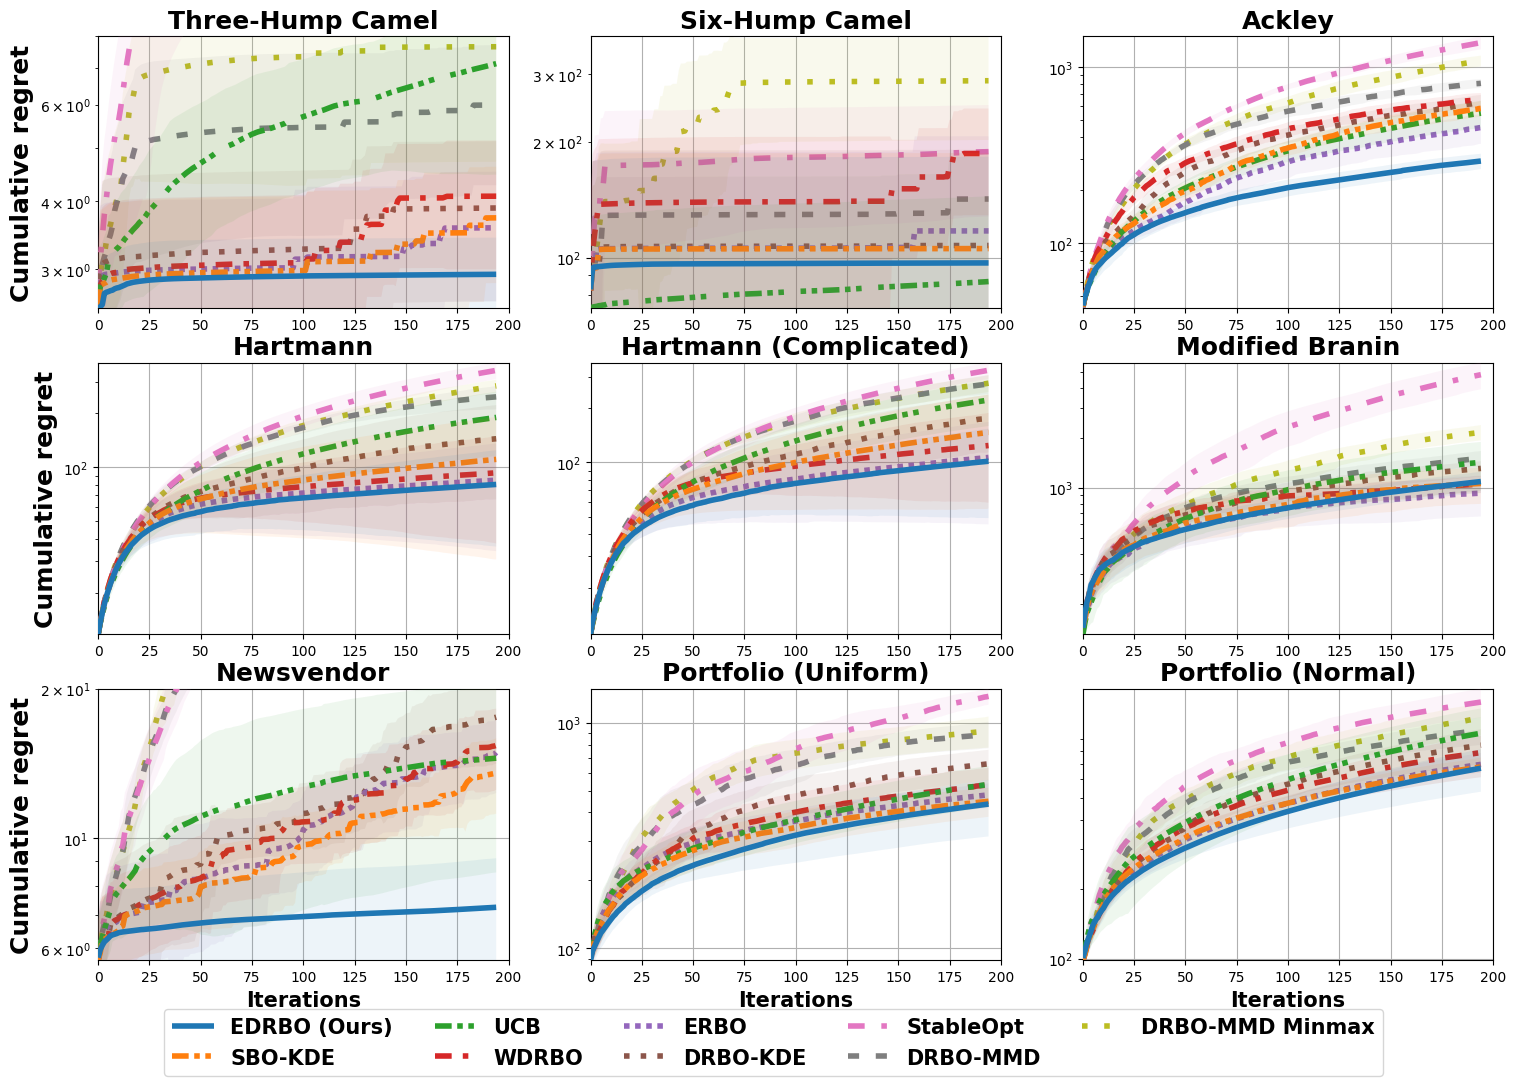

In [21]:
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(18, 12))

for i, f in enumerate(functions):
    
    ax_ = ax[i//3][i%3]
    
    mins, maxs = [], []
    # if i == 5:
    #     axins = ax_.inset_axes([0.5, 0.1, 0.4, 0.4])
    
    for j, m in enumerate(models):
        
        if 'WDRBO' in m:
            continue
        
        res_i = res[f][m]
        
        if 'LED' in m:
            z = 11
        else:
            z = 10 - j
        # print(z, method_to_name[m])
        
        # try:
        ax_.plot(res_i.mean(axis=0), label=method_to_name[m], zorder=z, linestyle=linestyles[m], linewidth=4)
        try:
            ax_.fill_between(np.arange(res_i.shape[1]),
                         res_i.mean(axis=0) - res_i.std(axis=0),
                         res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08, zorder=z)
        except:
            continue
        
        mins.append(np.min(res_i.mean(axis=0)))
        maxs.append(np.max(res_i.mean(axis=0) + res_i.std(axis=0)))
        
        # if i == 5:
        #     axins.plot(res_i.mean(axis=0), label=method_to_name[m])
        #     axins.fill_between(np.arange(res_i.shape[1]),
        #              res_i.mean(axis=0) - res_i.std(axis=0),
        #              res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08)
        
    
    ax_.set_title(name_to_title[f], fontweight='bold', fontsize=18)
    if i%3 == 0:
        ax_.set_ylabel('Cumulative regret', fontweight='bold', fontsize=18)
    if (i//3 == 2):
        ax_.set_xlabel('Iterations', fontweight='bold', fontsize=15)
    # if (i != 0):
    ax_.set_yscale('log')
    ax_.grid(True)
    
    mms = np.max(maxs)
    
    if i == 0:
        mms = 8e0
    elif i == 6:
        mms = 2e1
    
    mns = np.min(mins)
    
    ax_.set_ylim(mns, mms)
    ax_.set_xlim(0, 200)
    
    if i == 6:
        ax_.set_yticks([1e1], [r'$10^{1}$'])
    if i == 8:
        ax_.set_yticks([1e2], [r'$10^{2}$'])

handles = [
    Line2D([0, 0], [0, 1],
           color=f'C{i}',
           linewidth=4.0,
           linestyle=linestyles[m],
           label=method_to_name[m])
    for i, m in enumerate(models)
]
# handles = [mpatches.Patch(color=f'C{i}', label=method_to_name[m]) for i, m in enumerate(models)]
# plt.legend(handles=handles, loc='lower center', prop={'weight':'bold', 'size': 14})
fig.legend(handles=handles,
           loc='lower center',
           ncol=5,
           prop={'weight': 'bold', 'size': 15},
           bbox_to_anchor=(0.5, 0.005))

plt.savefig("images/lipschitz_cumulative_regret_full.pdf", format="pdf", dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

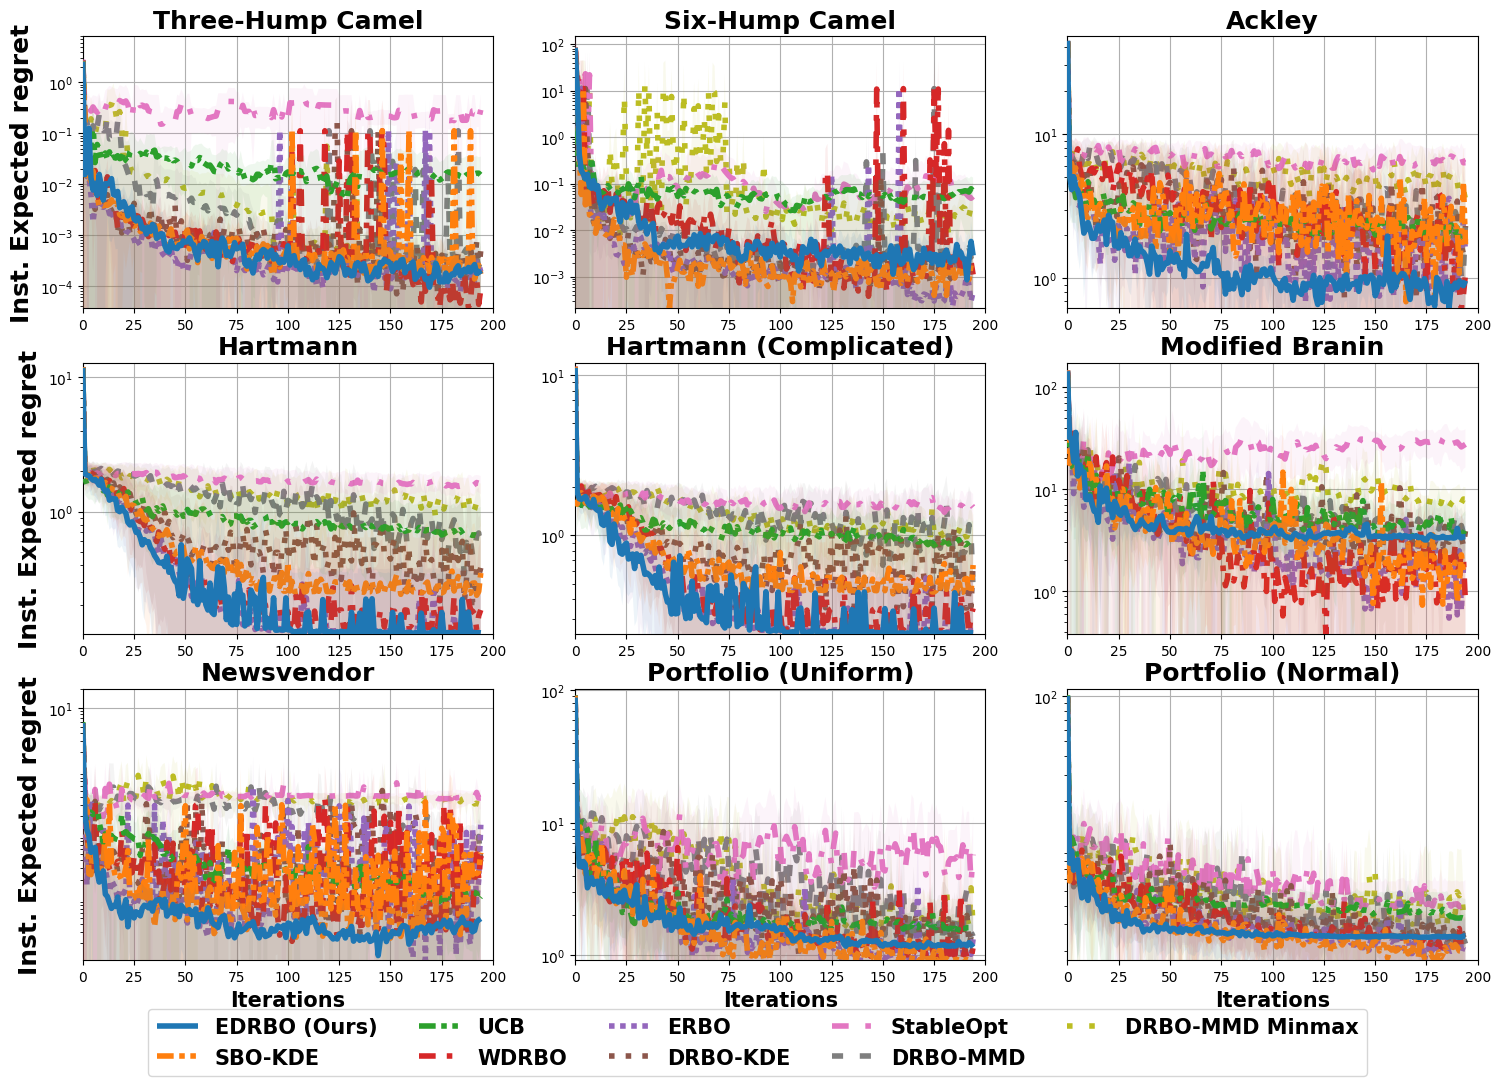

In [22]:
fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(18, 12))

for i, f in enumerate(functions):
    
    ax_ = ax[i//3][i%3]
    
    mins, maxs = [], []
    # if i == 5:
    #     axins = ax_.inset_axes([0.5, 0.1, 0.4, 0.4])
    
    for j, m in enumerate(models):
        
        res_i = np.diff(res[f][m], prepend=0)
        
        # np.cumsum(res[f][m][::-1])[::-1]
        
        z = 10 - j
        # print(z, method_to_name[m])
        
        # try:
        ax_.plot(res_i.mean(axis=0), label=method_to_name[m], zorder=z, linestyle=linestyles[m], linewidth=4)
        try:
            ax_.fill_between(np.arange(res_i.shape[1]),
                         res_i.mean(axis=0) - res_i.std(axis=0),
                         res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08, zorder=z)
        except:
            continue
        
        mins.append(np.min(res_i.mean(axis=0)))
        maxs.append(np.max(res_i.mean(axis=0) + res_i.std(axis=0)))
        
        # if i == 5:
        #     axins.plot(res_i.mean(axis=0), label=method_to_name[m])
        #     axins.fill_between(np.arange(res_i.shape[1]),
        #              res_i.mean(axis=0) - res_i.std(axis=0),
        #              res_i.mean(axis=0) + res_i.std(axis=0), alpha=0.08)
        
    
    ax_.set_title(name_to_title[f], fontweight='bold', fontsize=18)
    if i%3 == 0:
        ax_.set_ylabel('Inst. Expected regret', fontweight='bold', fontsize=18)
    if (i//3 == 2):
        ax_.set_xlabel('Iterations', fontweight='bold', fontsize=15)
    # if (i != 0):
    ax_.set_yscale('log')
    ax_.grid(True)
    
    mms = np.max(maxs)
    
    if i == 0:
        mms = 8e0
    elif i == 6:
        mms = 2e1
    
    mns = np.min(mins)
    
    ax_.set_ylim(mns, mms)
    ax_.set_xlim(0, 200)
    
    if i == 6:
        ax_.set_yticks([1e1], [r'$10^{1}$'])
    if i == 8:
        ax_.set_yticks([1e2], [r'$10^{2}$'])

handles = [
    Line2D([0, 0], [0, 1],
           color=f'C{i}',
           linewidth=4.0,
           linestyle=linestyles[m],
           label=method_to_name[m])
    for i, m in enumerate(models)
]
# handles = [mpatches.Patch(color=f'C{i}', label=method_to_name[m]) for i, m in enumerate(models)]
# plt.legend(handles=handles, loc='lower center', prop={'weight':'bold', 'size': 14})
fig.legend(handles=handles,
           loc='lower center',
           ncol=5,
           prop={'weight': 'bold', 'size': 15},
           bbox_to_anchor=(0.5, 0.005))

plt.savefig("images/lipschitz_instantaneous_expected_regret_full.pdf", format="pdf", dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()